# modeling5.ipynb — LOOCV, Zero Imputation, 5,000 Peptides

> Extends `modeling4.ipynb` by expanding the feature set from **200 to 5,000 peptides**.

**Hypothesis:** Peptides ranked 201–5,000 by Mann-Whitney U may carry collectively useful signal
that the top-200 cutoff discards. With zero imputation, "not detected" is a meaningful signal,
so more peptides could help.

**Risk:** p/n ≈ 5000/42 ≈ 119 — classic p >> n territory. L1 regularisation (`C=0.05`, stronger
than the `C=0.2` used in modeling4) mitigates this by zeroing out uninformative peptides.
L2 and Random Forest are included for comparison but are more susceptible to the high feature count.

**Everything else is identical to `modeling4.ipynb`:** zero imputation, LOOCV, feature selection
inside the loop on 42 training patients only, no data leakage.

## Step 1 — Load the full cleaned dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.model_selection import LeaveOneOut
from sklearn.base import clone

df        = pd.read_csv("variants_filtered.tsv", sep="\t", index_col=0)
condition = df["Condition"]
X         = df.drop(columns=["Condition"])
y         = condition.map({"Non-severe-COVID-19": 0, "Severe-COVID-19": 1})

print(f"Full dataset : {X.shape[0]} patients x {X.shape[1]} peptides")
print(f"Condition counts:")
print(condition.value_counts())
print(f"Missing value rate: {X.isna().mean().mean():.1%} -- filled with 0 (zero imputation)")
print(f"\nFeatures used for modelling : 5,000  (vs 200 in modeling3/modeling4)")

Full dataset : 43 patients x 101461 peptides
Condition counts:
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64
Missing value rate: 59.0% -- filled with 0 (zero imputation)

Features used for modelling : 5,000  (vs 200 in modeling3/modeling4)


## Step 2 — Define model pipelines

Same three models as `modeling4.ipynb` with two changes:
- **`N_FEATURES = 5000`** — top 5,000 peptides selected per fold instead of 200
- **L1 `C=0.05`** (was `0.2`) — stronger regularisation to compensate for the 25x more features;
  L1 must zero out ~4,800 uninformative peptides so a tighter penalty is appropriate

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
N_FEATURES   = 5000   # expanded from 200

model_templates = {
    "logistic_regression_l2": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l2", C=1.0, class_weight="balanced",
            max_iter=10000, random_state=RANDOM_STATE,
        )),
    ]),
    "logistic_regression_l1": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l1", C=0.05, solver="liblinear", class_weight="balanced",
            max_iter=10000, random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("model",   RandomForestClassifier(
            n_estimators=500, max_depth=3, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ]),
}

print("Model templates (zero imputation, N_FEATURES=5000):")
for name, pipe in model_templates.items():
    imp = pipe.named_steps["imputer"]
    mdl = pipe.named_steps["model"]
    C   = getattr(mdl, "C", "n/a")
    print(f"  {name}: fill_value={imp.fill_value}, C={C}")

Model templates (zero imputation, N_FEATURES=5000):
  logistic_regression_l2: fill_value=0, C=1.0
  logistic_regression_l1: fill_value=0, C=0.05
  random_forest: fill_value=0, C=n/a


## Step 3 — LOOCV loop

Identical to `modeling4.ipynb` except `N_FEATURES = 5000`.
Feature selection uses vectorised scipy calls (`axis=0`) across all ~101k peptides,
then selects the top 5,000 by Mann-Whitney p-value.

In [3]:
loo = LeaveOneOut()

loocv_results = {
    name: {"y_true": [], "y_pred": [], "y_score": []}
    for name in model_templates
}

for fold, (train_idx, test_idx) in enumerate(loo.split(X)):
    X_train_fold = X.iloc[train_idx]   # 42 patients
    X_test_fold  = X.iloc[test_idx]    # 1 patient
    y_train_fold = y.iloc[train_idx]
    y_test_fold  = y.iloc[test_idx]

    # ---- Feature selection on training fold only --------------------------------
    condition_fold = y_train_fold.map({0: "Non-severe-COVID-19", 1: "Severe-COVID-19"})
    X_sv_arr  = X_train_fold.loc[condition_fold == "Severe-COVID-19"].values.astype(float)
    X_nsv_arr = X_train_fold.loc[condition_fold == "Non-severe-COVID-19"].values.astype(float)

    n_sv  = np.sum(~np.isnan(X_sv_arr),  axis=0)
    n_nsv = np.sum(~np.isnan(X_nsv_arr), axis=0)
    valid = (n_sv >= 3) & (n_nsv >= 3)

    _, t_pvals  = ttest_ind(X_sv_arr, X_nsv_arr, axis=0, equal_var=False, nan_policy="omit")
    _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
    t_pvals[~valid]  = np.nan
    mw_pvals[~valid] = np.nan

    stats_fold = (
        pd.DataFrame({
            "Peptide"            : X_train_fold.columns,
            "mannwhitney_pvalue" : mw_pvals,
            "t_pvalue"           : t_pvals,
        })
        .sort_values(["mannwhitney_pvalue", "t_pvalue"], na_position="last")
        .reset_index(drop=True)
    )
    selected = (
        stats_fold
        .dropna(subset=["mannwhitney_pvalue"])
        .head(N_FEATURES)["Peptide"]
        .tolist()
    )

    X_tr = X_train_fold[selected]
    X_te = X_test_fold[selected]

    # ---- Train each model and predict the held-out patient ----------------------
    for name, template in model_templates.items():
        pipe = clone(template)
        pipe.fit(X_tr, y_train_fold)
        pred  = pipe.predict(X_te)[0]
        score = pipe.predict_proba(X_te)[0, 1]
        loocv_results[name]["y_true"].append(y_test_fold.iloc[0])
        loocv_results[name]["y_pred"].append(pred)
        loocv_results[name]["y_score"].append(score)

    if (fold + 1) % 10 == 0 or (fold + 1) == len(y):
        print(f"Fold {fold+1:2d}/{len(y)} complete")

print("\nLOOCV complete.")

c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_10924\551518862.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation fo

Fold 10/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_10924\551518862.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation fo

Fold 20/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_10924\551518862.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation fo

Fold 30/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_10924\551518862.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation fo

Fold 40/43 complete


c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_10924\551518862.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_pvals = mannwhitneyu(X_sv_arr, X_nsv_arr, axis=0, alternative="two-sided", nan_policy="omit")
c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation fo

Fold 43/43 complete

LOOCV complete.


## Step 4 — Compare model performance across all 43 folds

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

comparison_rows = []
for name, res in loocv_results.items():
    comparison_rows.append({
        "model"            : name,
        "accuracy"         : accuracy_score(res["y_true"], res["y_pred"]),
        "precision_severe" : precision_score(res["y_true"], res["y_pred"], zero_division=0),
        "recall_severe"    : recall_score(res["y_true"], res["y_pred"], zero_division=0),
        "f1_severe"        : f1_score(res["y_true"], res["y_pred"], zero_division=0),
        "roc_auc"          : roc_auc_score(res["y_true"], res["y_score"]),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["f1_severe", "roc_auc", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("LOOCV results — zero imputation, 5,000 peptides (aggregated across 43 folds):")
print(model_comparison.to_string(index=False))

LOOCV results — zero imputation, 5,000 peptides (aggregated across 43 folds):
                 model  accuracy  precision_severe  recall_severe  f1_severe  roc_auc
logistic_regression_l2  0.813953            0.8125       0.722222   0.764706 0.926667
         random_forest  0.674419            0.7000       0.388889   0.500000 0.773333
logistic_regression_l1  0.581395            0.0000       0.000000   0.000000 0.500000


## Step 5 — Select best model and inspect per-patient predictions

In [5]:
from sklearn.metrics import classification_report

best_model_name = model_comparison.loc[0, "model"]
best_res        = loocv_results[best_model_name]

predictions_df = pd.DataFrame({
    "patient"            : X.index,
    "true_condition"     : pd.Series(best_res["y_true"]).map({0: "Non-severe", 1: "Severe"}).values,
    "predicted_condition": pd.Series(best_res["y_pred"]).map({0: "Non-severe", 1: "Severe"}).values,
    "severe_probability" : best_res["y_score"],
    "correct"            : [t == p for t, p in zip(best_res["y_true"], best_res["y_pred"])],
})

print(f"Best model: {best_model_name}")
print(f"\nPer-patient LOOCV predictions:")
print(predictions_df.to_string(index=False))
print(f"\n-- LOOCV Metrics ({best_model_name}) --")
print(f"Accuracy  : {accuracy_score(best_res['y_true'], best_res['y_pred']):.3f}")
print(f"Precision : {precision_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"Recall    : {recall_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"F1        : {f1_score(best_res['y_true'], best_res['y_pred'], zero_division=0):.3f}")
print(f"ROC-AUC   : {roc_auc_score(best_res['y_true'], best_res['y_score']):.3f}")
print()
print(classification_report(
    best_res["y_true"], best_res["y_pred"],
    target_names=["Non-severe", "Severe"], zero_division=0
))

Best model: logistic_regression_l2

Per-patient LOOCV predictions:
                             patient true_condition predicted_condition  severe_probability  correct
Non-severe-COVID-19.Patient-group-PT     Non-severe          Non-severe            0.039406     True
             Non-severe-COVID-19.XG1     Non-severe          Non-severe            0.002372     True
            Non-severe-COVID-19.XG10     Non-severe          Non-severe            0.164203     True
            Non-severe-COVID-19.XG11     Non-severe          Non-severe            0.003144     True
            Non-severe-COVID-19.XG13     Non-severe          Non-severe            0.002782     True
            Non-severe-COVID-19.XG14     Non-severe          Non-severe            0.006405     True
            Non-severe-COVID-19.XG15     Non-severe          Non-severe            0.005023     True
            Non-severe-COVID-19.XG16     Non-severe          Non-severe            0.000506     True
            Non-severe-C

## Step 6 — Confusion Matrix

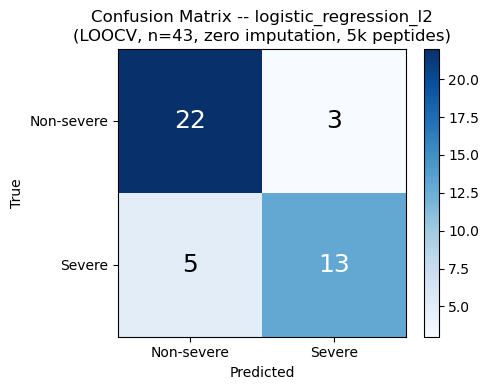

True Negatives  (Non-severe -> Non-severe): 22
False Positives (Non-severe -> Severe)    : 3
False Negatives (Severe -> Non-severe)    : 5
True Positives  (Severe -> Severe)        : 13


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(best_res["y_true"], best_res["y_pred"])
labels = ["Non-severe", "Severe"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix -- {best_model_name}\n(LOOCV, n=43, zero imputation, 5k peptides)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=18, color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Non-severe -> Non-severe): {tn}")
print(f"False Positives (Non-severe -> Severe)    : {fp}")
print(f"False Negatives (Severe -> Non-severe)    : {fn}")
print(f"True Positives  (Severe -> Severe)        : {tp}")

## Step 7 — Precision-Recall Curve

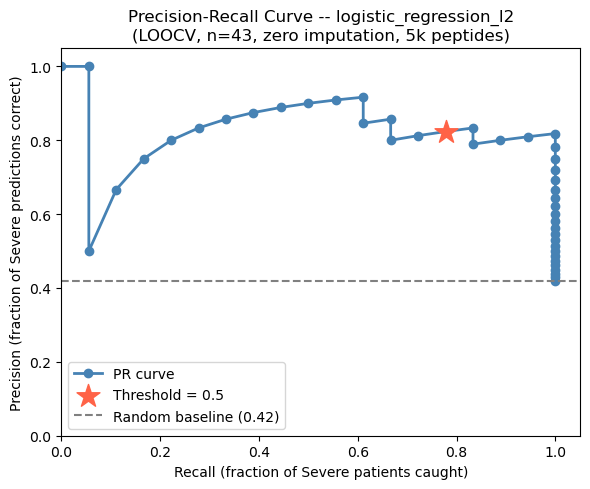

In [7]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    best_res["y_true"], best_res["y_score"]
)
default_idx = np.argmin(np.abs(thresholds - 0.5))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_vals, precision_vals, marker="o", color="steelblue", linewidth=2, label="PR curve")
ax.scatter(recall_vals[default_idx], precision_vals[default_idx],
           marker="*", s=300, color="tomato", zorder=5, label="Threshold = 0.5")
ax.axhline(np.mean(best_res["y_true"]), linestyle="--", color="grey",
           label=f"Random baseline ({np.mean(best_res['y_true']):.2f})")
ax.set_xlabel("Recall (fraction of Severe patients caught)")
ax.set_ylabel("Precision (fraction of Severe predictions correct)")
ax.set_title(f"Precision-Recall Curve -- {best_model_name}\n(LOOCV, n=43, zero imputation, 5k peptides)")
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — Three-way comparison: 200 (median) vs 200 (zero) vs 5,000 (zero)

Compares this notebook against both previous LOOCV pipelines using their best models.

In [8]:
# Results from checkpoint6.md (modeling3) and checkpoint7.md (modeling4)
prior_results = {
    "200 peptides, median imputation (modeling3)": {
        "accuracy": 0.906977, "precision_severe": 0.888889,
        "recall_severe": 0.888889, "f1_severe": 0.888889, "roc_auc": 0.944444,
    },
    "200 peptides, zero imputation   (modeling4)": {
        "accuracy": 0.906977, "precision_severe": 0.888889,
        "recall_severe": 0.888889, "f1_severe": 0.888889, "roc_auc": 0.966667,
    },
}

best_loocv = model_comparison.iloc[0]
current = {
    f"5000 peptides, zero imputation  (modeling5)": {
        "accuracy"         : best_loocv["accuracy"],
        "precision_severe" : best_loocv["precision_severe"],
        "recall_severe"    : best_loocv["recall_severe"],
        "f1_severe"        : best_loocv["f1_severe"],
        "roc_auc"          : best_loocv["roc_auc"],
    }
}

three_way = pd.DataFrame({**prior_results, **current}).T
print(f"Best model (5k peptides): {best_model_name}")
print()
print(three_way.round(3).to_string())

Best model (5k peptides): logistic_regression_l2

                                             accuracy  precision_severe  recall_severe  f1_severe  roc_auc
200 peptides, median imputation (modeling3)     0.907             0.889          0.889      0.889    0.944
200 peptides, zero imputation   (modeling4)     0.907             0.889          0.889      0.889    0.967
5000 peptides, zero imputation  (modeling5)     0.814             0.812          0.722      0.765    0.927


## Step 9 — Save results and retrain final model on all 43 patients

Performance was already estimated by LOOCV. Retraining on all 43 patients produces a final
model for feature importance inspection.

In [9]:
import joblib

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

model_comparison.to_csv(MODEL_DIR / "modeling5_loocv_comparison.tsv",  sep="\t", index=False)
predictions_df.to_csv(  MODEL_DIR / "modeling5_loocv_predictions.tsv", sep="\t", index=False)

# Feature selection on all 43 patients for the final model
X_sv_all  = X.loc[y == 1].values.astype(float)
X_nsv_all = X.loc[y == 0].values.astype(float)

n_sv_all  = np.sum(~np.isnan(X_sv_all),  axis=0)
n_nsv_all = np.sum(~np.isnan(X_nsv_all), axis=0)
valid_all  = (n_sv_all >= 3) & (n_nsv_all >= 3)

_, t_all  = ttest_ind(X_sv_all, X_nsv_all, axis=0, equal_var=False, nan_policy="omit")
_, mw_all = mannwhitneyu(X_sv_all, X_nsv_all, axis=0, alternative="two-sided", nan_policy="omit")
t_all[~valid_all]  = np.nan
mw_all[~valid_all] = np.nan

stats_all_df = (
    pd.DataFrame({
        "Peptide": X.columns, "mannwhitney_pvalue": mw_all, "t_pvalue": t_all,
    })
    .sort_values(["mannwhitney_pvalue", "t_pvalue"], na_position="last")
    .reset_index(drop=True)
)
final_peptides = stats_all_df.dropna(subset=["mannwhitney_pvalue"]).head(N_FEATURES)["Peptide"].tolist()

final_model = clone(model_templates[best_model_name])
final_model.fit(X[final_peptides], y)

joblib.dump(final_model, MODEL_DIR / "modeling5_final_model.joblib")
(MODEL_DIR / "modeling5_best_model_name.txt").write_text(best_model_name + "\n")
pd.Series(final_peptides).to_csv(MODEL_DIR / "modeling5_selected_peptides.txt", index=False, header=False)

print("Saved:")
print("  modeling5_loocv_comparison.tsv   -- LOOCV metrics for all 3 models")
print("  modeling5_loocv_predictions.tsv  -- per-patient predictions from best model")
print("  modeling5_final_model.joblib     -- best model retrained on all 43 patients")
print("  modeling5_best_model_name.txt    -- best model name")
print("  modeling5_selected_peptides.txt  -- 5,000 peptides selected from full dataset")

c:\Users\Melvyn Tan\miniconda3\envs\CSE253\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
C:\Users\Melvyn Tan\AppData\Local\Temp\ipykernel_10924\2207859950.py:18: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  _, mw_all = mannwhitneyu(X_sv_all, X_nsv_all, axis=0, alternative="two-sided", nan_policy="omit")


Saved:
  modeling5_loocv_comparison.tsv   -- LOOCV metrics for all 3 models
  modeling5_loocv_predictions.tsv  -- per-patient predictions from best model
  modeling5_final_model.joblib     -- best model retrained on all 43 patients
  modeling5_best_model_name.txt    -- best model name
  modeling5_selected_peptides.txt  -- 5,000 peptides selected from full dataset
